### makemore: part 5

![image](images/idontwantajob.jpg)

In [129]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [130]:
words = open('src/names.txt', 'r').read().splitlines()
print(words[:8], len(words))
chars = sorted(list(set(''.join(words))))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos, stoi,vocab_size)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'] 32033
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'} {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0} 27


In [131]:
block_size = 8

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [132]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

........ ---> y
.......y ---> u
......yu ---> h
.....yuh ---> e
....yuhe ---> n
...yuhen ---> g
..yuheng ---> .
........ ---> d
.......d ---> i
......di ---> o
.....dio ---> n
....dion ---> d
...diond ---> r
..diondr ---> e
.diondre ---> .
........ ---> x
.......x ---> a
......xa ---> v
.....xav ---> i
....xavi ---> e


In [133]:
# Let's train a deeper network.
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        g           = torch.Generator().manual_seed(2147483647)
        # Kaiming initialization
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in ** 0.5
        self.bias   = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    """affine will be true which means using gamma and beta during training.
    track_running_stats will be true, keep tracking running mean and variance.
    device by default is cpu(but i hope is gpu.).
    datatype float32.
    """
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True

        # parameters (trained with backprop.)
        self.gamma = torch.ones(dim)
        self.beta  = torch.zeros(dim)

        # buffers (trained with a running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass.
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim = True) # batch mean
            xvar  =  x.var(dim, keepdim = True)  # batch variance
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalized to unit variance
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn(num_embeddings, embedding_dim)

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [134]:
torch.manual_seed(42)

In [135]:
n_embd = 24
n_hidd = 128

# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidd, bias = False), BatchNorm1d(n_hidd), Tanh(),
    FlattenConsecutive(2), Linear(n_hidd * 2, n_hidd, bias = False), BatchNorm1d(n_hidd), Tanh(),
    FlattenConsecutive(2), Linear(n_hidd * 2, n_hidd, bias = False), BatchNorm1d(n_hidd), Tanh(),
    Linear(n_hidd, vocab_size),
])

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = model.parameters()
print("param_num: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

param_num:  76579


In [136]:
max_steps   = 200000
batch_size  = 32
lossi       = []
ud          = []

for i in range(200000):

    # minibatch construct
    ix      = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb  = Xtr[ix], Ytr[ix] # Batch X and Y.

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    # for layer in layers:
    #     layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"{i: 7d}/{max_steps: 7d}, loss: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    # break

print(f"{i: 7d}/{max_steps: 7d}, loss: {loss.item():.4f}")

      0/ 200000, loss: 3.5113
  10000/ 200000, loss: 2.3085
  20000/ 200000, loss: 1.9942
  30000/ 200000, loss: 1.8200
  40000/ 200000, loss: 1.9210
  50000/ 200000, loss: 1.9281
  60000/ 200000, loss: 1.9158
  70000/ 200000, loss: 1.8415
  80000/ 200000, loss: 1.7840
  90000/ 200000, loss: 2.3628
 100000/ 200000, loss: 1.9907
 110000/ 200000, loss: 1.5588
 120000/ 200000, loss: 1.7580
 130000/ 200000, loss: 1.9374
 140000/ 200000, loss: 1.7111
 150000/ 200000, loss: 1.5444
 160000/ 200000, loss: 1.8791
 170000/ 200000, loss: 1.8364
 180000/ 200000, loss: 2.0156
 190000/ 200000, loss: 1.6997
 199999/ 200000, loss: 1.7625


In [142]:
for layer in model.layers:
    print(layer.__class__.__name__, tuple(layer.out.shape))

Embedding (1, 8, 24)
FlattenConsecutive (1, 4, 48)
Linear (1, 4, 128)
BatchNorm1d (1, 4, 128)
Tanh (1, 4, 128)
FlattenConsecutive (1, 2, 256)
Linear (1, 2, 128)
BatchNorm1d (1, 2, 128)
Tanh (1, 2, 128)
FlattenConsecutive (1, 256)
Linear (1, 128)
BatchNorm1d (1, 128)
Tanh (1, 128)
Linear (1, 27)


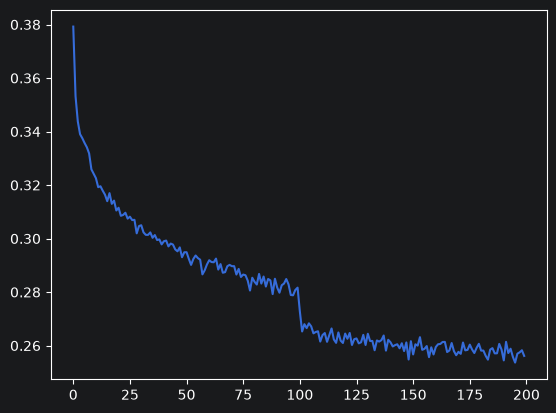

In [143]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [144]:
for layer in model.layers:
    layer.training = False

In [145]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'valid': (Xdev,Ydev),
        'test ': (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('valid')
split_loss('test ')

train 1.7882031202316284
valid 1.9931516647338867
test  1.9919686317443848


In [146]:
# sample from the model

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

lovelton.
attherin.
laikaela.
amalah.
auri.
cayleigh.
phood.
glensie.
trulan.
osway.
anzey.
ayda.
eunas.
diona.
colsleigh.
suo.
jatteren.
jerine.
whytus.
kaylie.
